# Bayesian Portolio Optimizer

### Install Libraries

In [139]:
pip install cvxpy

In [140]:
pip install yfinance --upgrade

### Load Libraries

In [141]:
import os
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import yfinance as yf
import matplotlib.ticker as mtick

# Bayesian modeling
import pymc as pm
import arviz as az

# Optimization
import cvxpy as cp
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize

### 1) Model Configuration & Assumptions

In [142]:
# 0) Date ranges for train / test
TRAIN_START = "2013-01-01"
TRAIN_END   = "2018-12-31"
TEST_START  = "2019-01-01"
TEST_END    = "2024-12-31"

In [143]:
# Configuration & Assumptions
ASSET_TICKERS = {
    "Large Cap":               "IVV",
    "Mid Cap":                 "IJH",
    "Small Cap":               "IJR",
    "Intl Dev Equity":         "VEA",
    "Emerging Market Equity":  "EEM",
    "Intermediate Bonds":      "IEF",
    "T-Bill":                  "SHV",
    "REIT":                    "VNQ",
    "Commodities":             "DBC"
}

### 2) Data Retrieval & Preprocessing

In [144]:
# Helper: fetch adjusted close prices
def fetch_adjusted_close(tickers: dict, start: str, end: str) -> pd.DataFrame:
    data = yf.download(
        list(tickers.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False
    )
    df = data["Adj Close"].rename(columns={ticker: asset for asset, ticker in tickers.items()})
    return df.ffill()

# Load training data
prices_train = fetch_adjusted_close(ASSET_TICKERS, TRAIN_START, TRAIN_END)
returns_train = np.log(prices_train / prices_train.shift(1)).dropna()

In [145]:
# Mapping assets to groups
group_idx = {
    "Large Cap":              0,
    "Mid Cap":                0,
    "Small Cap":              0,
    "Intl Dev Equity":        1,
    "Emerging Market Equity": 1,
    "Intermediate Bonds":     2,
    "T-Bill":                 2,
    "REIT":                   3,
    "Commodities":            3
}
asset_idx = [group_idx[a] for a in returns_train.columns]

n_assets = len(returns_train.columns)
n_groups = len(set(asset_idx))

### 3. Portfolio Optimization Functions

#### 3.1 Maximize Sharpe Ratio

In [232]:
def max_sharpe_ratio(expected_returns, cov_matrix, risk_free_rate=0.0):
    """
    Compute portfolio weights that maximize the Sharpe ratio:
      Sharpe = (wᵀμ - rf) / sqrt(wᵀΣw)
    """
    n = len(expected_returns)

    def neg_sharpe(w):
        ret = w.dot(expected_returns)
        vol = np.sqrt(w.T @ cov_matrix @ w)
        return -(ret - risk_free_rate) / vol

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init = np.ones(n) / n

    result = minimize(
        neg_sharpe,
        init,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result.x


#### 3.2 Optimize Mean Variance

In [233]:
def optimize_mean_variance(expected_returns, cov_matrix, risk_free_rate=0.0):
    """
    Compute the tangency (mean‐variance efficient) portfolio:
      w ∝ Σ⁻¹ (μ − rₙ),  then enforce w ≥ 0 and sum(w)=1.
    """
    # 1) compute excess returns
    mu_excess = expected_returns - risk_free_rate

    # 2) invert the covariance
    inv_cov = np.linalg.inv(cov_matrix)

    # 3) raw (unconstrained) weights
    w_raw = inv_cov.dot(mu_excess)

    # 4) no‐shorting: zero out any negatives
    w_clipped = np.clip(w_raw, 0, None)

    # 5) normalize to sum to 1
    return w_clipped / w_clipped.sum()

#### 3.3 Optimize cVar (Conditional value at Risk)

In [234]:
def optimize_cvar(returns_history, alpha=0.05):
    """
    Minimize portfolio CVaR at level alpha.
    Requires historical return simulations in `returns_history`
    shape=(n_sims, n_assets).
    """
    n_assets = returns_history.shape[1]

    def portfolio_cvar(weights):
        # Compute portfolio returns across simulations
        port_rets = returns_history @ weights
        var = np.percentile(port_rets, 100 * alpha)
        cvar = port_rets[port_rets <= var].mean()
        return cvar  # lower is better

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n_assets))
    init = np.ones(n_assets) / n_assets

    result = minimize(
        portfolio_cvar,
        init,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result.x

### 4) Portfolio Construction Models:

- Static-Weights Portfolios
- Monte Carlo Sampling & Distribution Metrics
- Bayesian Hierarchical MCMC Model (PyMC)

### 4.1 Static-Weights Portfolios

In [235]:
# Static Weights Portfolio

# Define weights by asset‐class for each portfolio
BASE_PORTFOLIO_WEIGHTS = {
    "Aggressive": {  # ~90% equity, 5% bonds, 5% cash
        "Large Cap":               0.20,
        "Mid Cap":                 0.20,
        "Small Cap":               0.15,
        "Intl Dev Equity":         0.15,
        "Emerging Market Equity":  0.10,
        "REIT":                    0.05,
        "Commodities":             0.05,
        "Intermediate Bonds":      0.05,
        "T-Bill":                  0.05,
    },
    "Balanced": {   # ~60% equity, 30% bonds, 10% cash
        "Large Cap":               0.15,
        "Mid Cap":                 0.10,
        "Small Cap":               0.10,
        "Intl Dev Equity":         0.10,
        "Emerging Market Equity":  0.05,
        "REIT":                    0.05,
        "Commodities":             0.05,
        "Intermediate Bonds":      0.30,
        "T-Bill":                  0.10,
    },
    "Conservative": {  # ~30% equity, 50% bonds, 20% cash
        "Large Cap":               0.10,
        "Mid Cap":                 0.05,
        "Small Cap":               0.05,
        "Intl Dev Equity":         0.05,
        "Emerging Market Equity":  0.03,
        "REIT":                    0.01,
        "Commodities":             0.01,
        "Intermediate Bonds":      0.50,
        "T-Bill":                  0.20,
    },
}

# 2) Convert each to a pd.Series of {ticker: weight}
STATIC_WEIGHTS = {
    name: pd.Series({
        ASSET_TICKERS[asset_class]: weight
        for asset_class, weight in base.items()
    })
    for name, base in BASE_PORTFOLIO_WEIGHTS.items()
}

# Quick sanity check
print(STATIC_WEIGHTS["Aggressive"])

IVV    0.20
IJH    0.20
IJR    0.15
VEA    0.15
EEM    0.10
VNQ    0.05
DBC    0.05
IEF    0.05
SHV    0.05
dtype: float64


### 4.2 Monte Carlo Sampling & Distribution Metrics

In [236]:
def estimate_params(returns_df: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """
    1) Estimate the per‐asset mean vector and covariance matrix.
    """
    return returns_df.mean(), returns_df.cov()

In [237]:
def simulate_returns(mu: pd.Series,
                     cov: pd.DataFrame,
                     n_simulations: int = 10_000) -> pd.DataFrame:
    """
    2) Draw n_simulations of multivariate‐normal returns.
    """
    sims = np.random.multivariate_normal(mu.values, cov.values, size=n_simulations)
    return pd.DataFrame(sims, columns=mu.index)

In [238]:
def compute_metrics(sim_df: pd.DataFrame,
                    alpha: float = 0.05) -> dict[str, pd.Series]:
    """
    3) From the simulated returns, compute:
       - mean    (per asset)
       - cov     (asset covariance)
       - VaR     at level alpha
       - CVaR    (expected shortfall) at level alpha
    """
    mean_sim = sim_df.mean()
    cov_sim  = sim_df.cov()
    var_sim  = sim_df.quantile(alpha)
    cvar_sim = sim_df.apply(lambda x: x[x <= var_sim[x.name]].mean())

    return {
        'mean': mean_sim,
        'cov':  cov_sim,
        'VaR':  var_sim,
        'CVaR': cvar_sim
    }

In [239]:
def monte_carlo_sampling_portfolios(
    returns_df: pd.DataFrame,
    rf_rate: float        = 0.1,
    n_simulations: int    = 10_000,
    alpha: float          = 0.05
) -> tuple[dict[str, np.ndarray], dict[str, pd.Series]]:
    """
    4) Full Monte Carlo workflow:
         • estimate parameters
         • simulate returns
         • compute distribution metrics
         • build three portfolios using your notebook’s optimizer functions

    Returns:
      portfolios – a dict with weight‐vectors for each strategy
      metrics    – the mean/cov/VaR/CVaR from the simulations
    """
    # 1) Estimate parameters
    mu, cov = estimate_params(returns_df)

    # 2) Simulate returns
    sim_df = simulate_returns(mu, cov, n_simulations)

    # 3) Compute distribution metrics
    metrics = compute_metrics(sim_df, alpha)

    # 4) Build portfolios
    portfolios = {
        'Mean-Variance': optimize_mean_variance(
                              metrics['mean'],
                              metrics['cov']
                          ),
        'Max-Sharpe':    max_sharpe_ratio(
                              metrics['mean'],
                              metrics['cov'],
                              risk_free_rate=rf_rate
                          ),
        f'CVaR ({int(alpha*100)}%)': optimize_cvar(
                              sim_df.values,
                              alpha=alpha
                          )
    }

    return portfolios, metrics

In [240]:
# 1) Run Monte Carlo sampling + build portfolios
rf_rate       = 0.01           # set your risk‐free rate here
n_simulations = 10_000         # or whatever you chose above
alpha         = 0.05           # 5% tail for VaR/CVaR

raw_mc_portfolios, mc_metrics = monte_carlo_sampling_portfolios(
    returns_train,
    rf_rate=rf_rate,
    n_simulations=n_simulations,
    alpha=alpha
)

# 2) Convert each numpy weight‐vector into a pd.Series with asset names:
asset_index   = returns_train.columns
mc_portfolios = {
    strat: pd.Series(weights, index=asset_index)
    for strat, weights in raw_mc_portfolios.items()
}

print("=== Monte Carlo Portfolio Weights ===")
display(pd.DataFrame(mc_portfolios))

=== Monte Carlo Portfolio Weights ===


,Mean-Variance,Max-Sharpe,CVaR (5%)
Ticker,,,
Commodities,0.000000,7.692909e-17,5.617212e-16
Emerging Market Equity,0.000000,1.000000e+00,1.000000e+00
Intermediate Bonds,0.007958,0.000000e+00,5.410910e-16
Mid Cap,0.000000,2.338619e-16,0.000000e+00
Small Cap,0.005697,1.040834e-15,1.909584e-14
Large Cap,0.015163,3.603939e-16,6.889638e-16
T-Bill,0.970176,0.000000e+00,4.073780e-16
Intl Dev Equity,0.001007,0.000000e+00,2.838455e-15
REIT,0.000000,1.943108e-16,2.096108e-15


In [241]:
# 2) Compute training moments
mu_train  = returns_train.mean()
cov_train = returns_train.cov()

# 3) Generate Monte Carlo draws
mc_draws = np.random.multivariate_normal(
    mu_train.values,
    cov_train.values,
    size=n_simulations
)

In [242]:
# 4) Run Section 3 optimizers on the Monte Carlo model

# 0) define asset_index so that your DataFrame has row labels
asset_index = returns_train.columns

# 1) compute the MC‐predicted mean vector & covariance matrix
mc_mu  = mc_draws.mean(axis=0)
mc_cov = np.cov(mc_draws, rowvar=False)

# 2) run each optimizer on the MC estimates
w_mc_mv     = optimize_mean_variance(mc_mu, mc_cov)
w_mc_sharpe = max_sharpe_ratio(mc_mu, mc_cov)       # uses default risk_free_rate=0
w_mc_cvar   = optimize_cvar(mc_draws, alpha=0.05)

# 3) assemble into your DataFrame
monte_carlo_weights_df = pd.DataFrame(
    {
      'Mean-Variance': w_mc_mv,
      'Max-Sharpe':     w_mc_sharpe,
      f'CVaR ({int(alpha*100)}%)': w_mc_cvar
    },
    index=asset_index
)

print("=== Monte Carlo Portfolio Weights ===")
display(monte_carlo_weights_df)

=== Monte Carlo Portfolio Weights ===


,Mean-Variance,Max-Sharpe,CVaR (5%)
Ticker,,,
Commodities,0.000000,2.912789e-10,9.715059e-16
Emerging Market Equity,0.000000,4.723160e-10,1.000000e+00
Intermediate Bonds,0.005736,3.081016e-03,1.118582e-16
Mid Cap,0.000000,4.762314e-09,0.000000e+00
Small Cap,0.009088,1.526416e-03,3.844147e-15
Large Cap,0.016627,4.828126e-03,1.884450e-16
T-Bill,0.967242,9.905644e-01,3.028213e-16
Intl Dev Equity,0.001307,1.013490e-09,0.000000e+00
REIT,0.000000,9.453841e-09,9.490954e-16


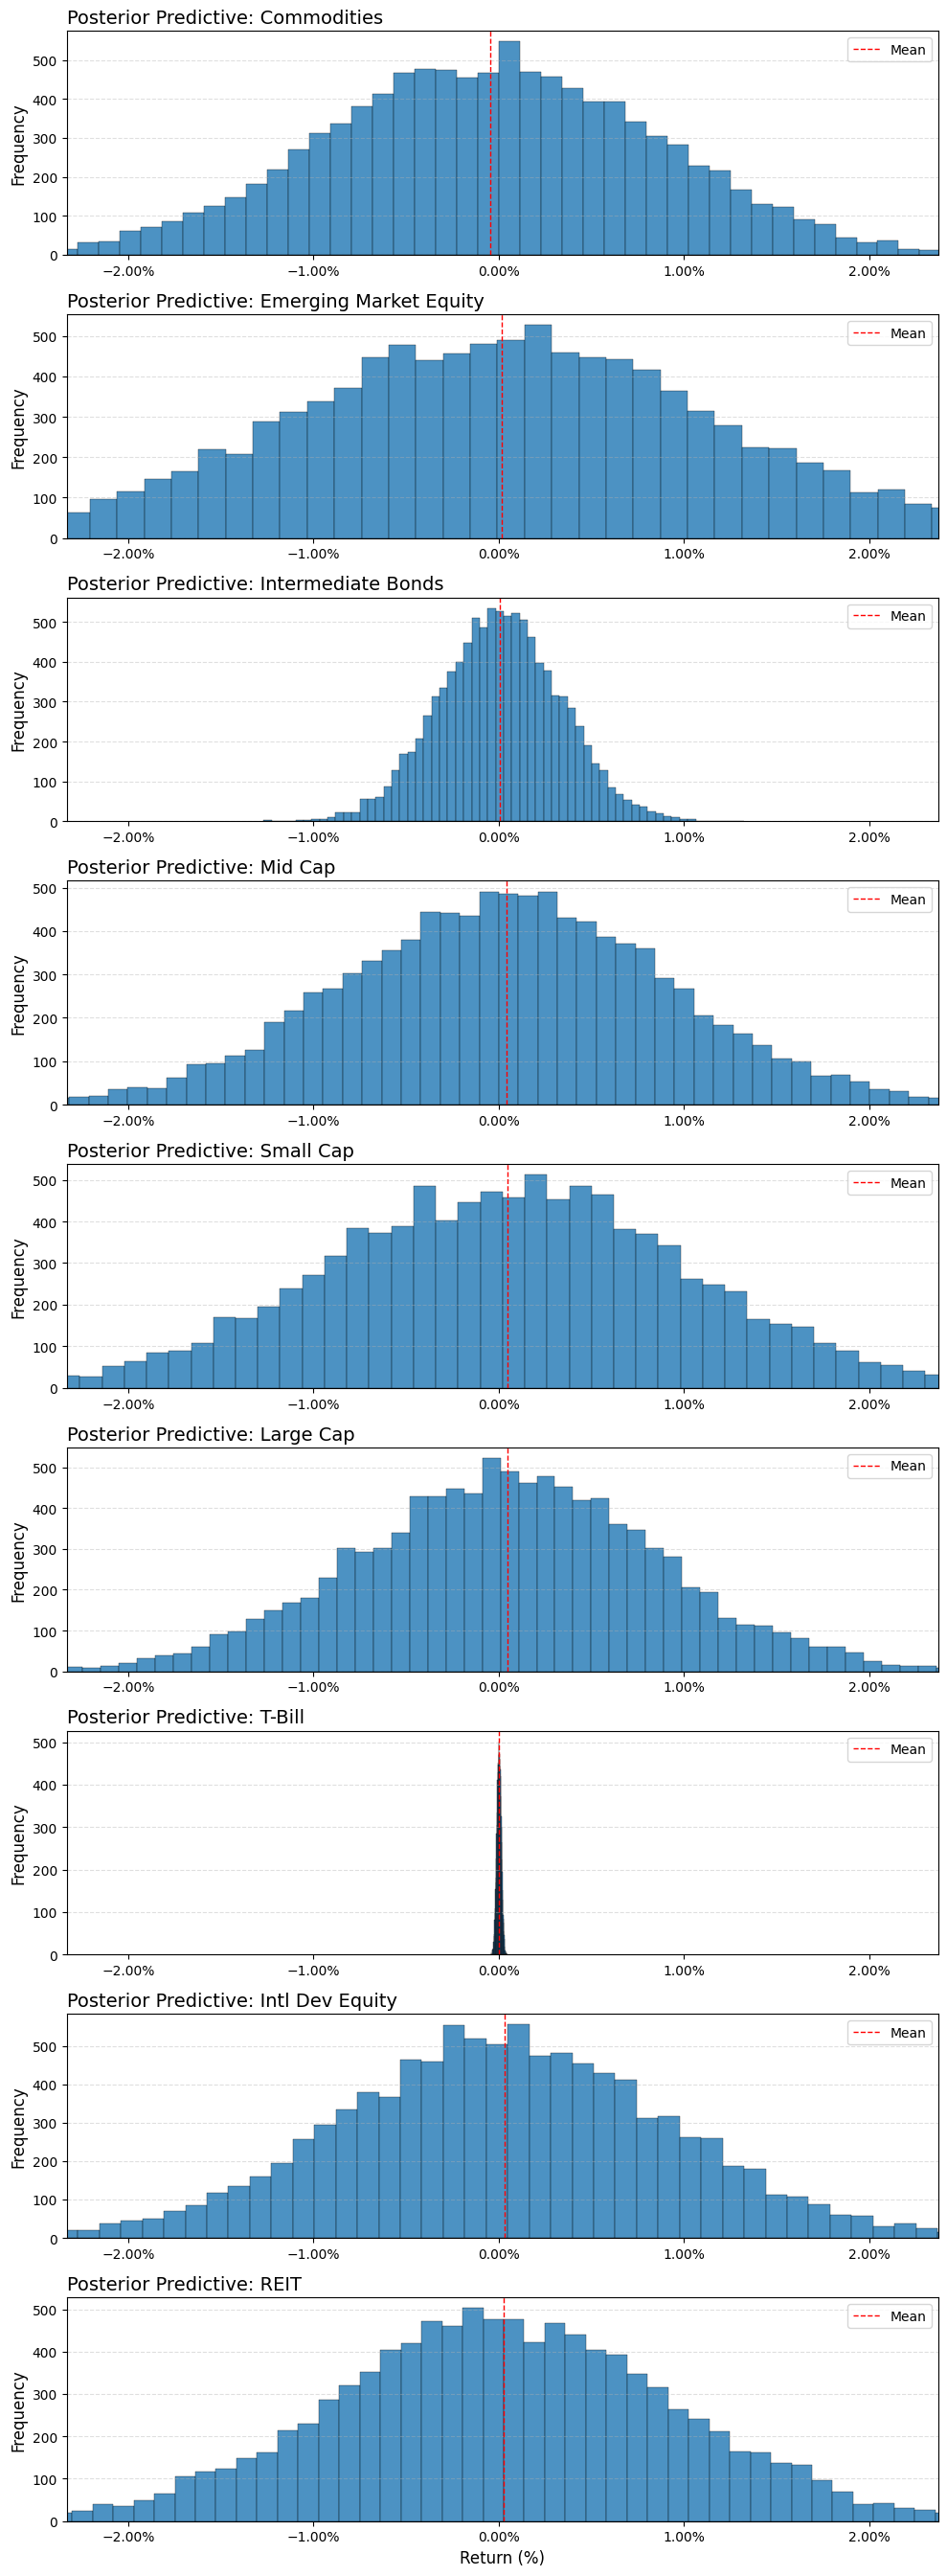

In [243]:
# estimate parameters from your training returns
mu, cov = returns_train.mean(), returns_train.cov()

# re-simulate
sim_df = simulate_returns(mu, cov, n_simulations)

# create assets variable
assets   = sim_df.columns.tolist()
n_assets = len(assets)

# plot
fig, axes = plt.subplots(n_assets, 1, figsize=(10, 3 * n_assets), sharex=True)

for ax, ticker in zip(axes, assets):
    data = sim_df[ticker]

    # histogram
    ax.hist(
        data,
        bins=60,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.3,
    )

    # mean line
    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=1,
        label="Mean"
    )

    # titles & labels
    ax.set_title(f"Posterior Predictive: {ticker}", loc="left", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=12)

    # grid only on y-axis
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # format x-axis as percent
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    # **force** x-tick labels to appear on every plot
    ax.tick_params(axis="x", labelbottom=True)

    # tighten x-limits to drop extreme tails
    lo, hi = data.quantile([0.005, 0.995])
    ax.set_xlim(lo, hi)

    ax.legend(loc="upper right", fontsize=10)

# bottom plot still gets the explicit x-label
axes[-1].set_xlabel("Return (%)", fontsize=12)

plt.tight_layout()
plt.show()

### 4.3 Bayesian Hierarchical MCMC Model (PyMC)

In [24]:
with pm.Model() as mcmc_model:

    # 1) Asset-class means
    mu = pm.Normal(
        name="mu",
        mu=0.0,
        sigma=0.1,
        shape=n_assets
    )

    # 2) Covariance via LKJ-Cholesky
    sd_dist = pm.HalfNormal.dist(
        sigma=1.0,
        shape=n_assets
    )
    L, corr, stds = pm.LKJCholeskyCov(
        name="chol_L",
        n=n_assets,       # number of assets
        eta=2,            # LKJ shape
        sd_dist=sd_dist,  # marginal SD dist
        compute_corr=True
    )

    # 3) (Optional) full covariance if you need it later
    Sigma = pm.Deterministic("Sigma", L.dot(L.T))

    # 4) Observation – feed the Cholesky factor straight in
    obs = pm.MvNormal(
        name="obs",
        mu=mu,
        chol=L,
        observed=returns_train
    )

    # 5) Sample the posterior
    trace = pm.sample(
        draws=3000,
        tune=1000,
        chains=4,
        target_accept=0.95
    )

/usr/local/lib/python3.11/dist-packages/pytensor/tensor/subtensor.py:2538: RuntimeWarning: invalid value encountered in add
  np.add.at(x, idx, y)
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/subtensor.py:2538: RuntimeWarning: invalid value encountered in add
  np.add.at(x, idx, y)
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/subtensor.py:2538: RuntimeWarning: invalid value encountered in add
  np.add.at(x, idx, y)
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/subtensor.py:2538: RuntimeWarning: invalid value encountered in add
  np.add.at(x, idx, y)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [177]:
# Use the returned InferenceData directly
idata = trace   # trace is already an arviz.InferenceData

# Save the full inference data to NetCDF
az.to_netcdf(idata, "bayesian_hierarchical_mcmc_trace.nc")

# Generate and save a summary table
summary_df = az.summary(idata, round_to=3)
summary_df.to_csv("bayesian_hierarchical_mcmc_summary.csv")

print("✅ Saved posterior draws to bayesian_hierarchical_mcmc_trace.nc")
print("✅ Saved summary stats to bayesian_hierarchical_mcmc_summary.csv")

/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


✅ Saved posterior draws to bayesian_hierarchical_mcmc_trace.nc
✅ Saved summary stats to bayesian_hierarchical_mcmc_summary.csv


In [244]:
# Posterior mean vector (shape = n_assets,)
mu_post = trace.posterior["mu"] \
    .mean(dim=("chain","draw")) \
    .values

# Stack chains & draws into one sample‐axis (shape = n_assets × n_samples)
mu_samples = trace.posterior["mu"] \
    .stack(samples=("chain","draw")) \
    .values

# Compute posterior covariance matrix from those samples
post_cov = np.cov(mu_samples)

In [256]:
# Define your list of asset names
asset_names = returns_train.columns.tolist()     # or: list(mu_post.index)

# Set n_assets to match
n_assets = len(asset_names)

# Define your η “tilts”
eta = {
    "Large Cap": 2.0,
    "Commodities": 1.0
}

# Start with zero tilt for every asset
tilt_vector = np.zeros(n_assets)

# Loop through assets, assigning η where specified
for i, name in enumerate(asset_names):
    tilt_vector[i] = eta.get(name, 0.0)

# Finally, add your tilts to the posterior means
adjusted_mu = mu_post + tilt_vector

In [257]:
# assume your trace is named "trace" and your asset names come from returns_train.columns
asset_names = returns_train.columns.tolist()

# summarize only the "mu" variables (posterior means of returns)
# adjust var_names if you used a different name
posterior_summary = az.summary(trace, var_names=["mu"], hdi_prob=0.90)
# rename and select the columns we want
posterior_metrics = posterior_summary.rename(
    columns={"mean": "Mean", "sd": "Std", "hdi_5%": "5%", "hdi_95%": "95%"}
)[["Mean", "Std", "5%", "95%"]]
posterior_metrics.index = asset_names  # match the index

# display as a nice table
display(posterior_metrics)

,Mean,Std,5%,95%
Commodities,-0.001,0.000,-0.001,-0.000
Emerging Market Equity,-0.000,0.001,-0.002,0.000
Intermediate Bonds,-0.000,0.001,-0.001,0.000
Mid Cap,0.000,0.000,-0.000,0.001
Small Cap,0.002,0.002,-0.000,0.006
Large Cap,0.069,0.113,-0.001,0.281
T-Bill,0.000,0.000,0.000,0.000
Intl Dev Equity,0.086,0.087,-0.001,0.203
REIT,-0.118,0.269,-0.584,0.128


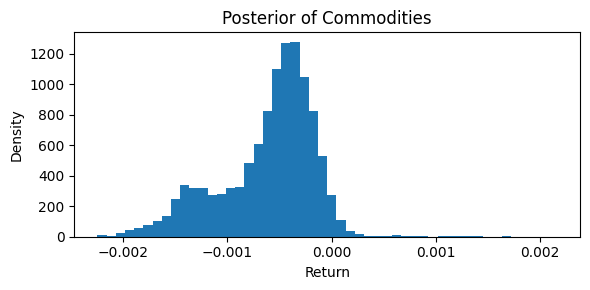

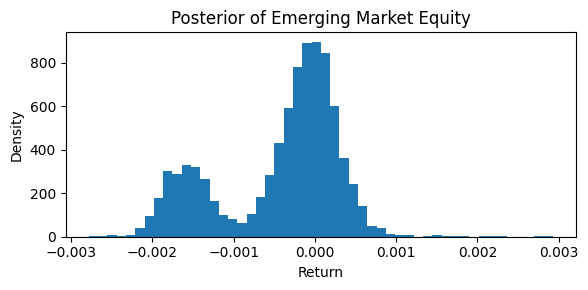

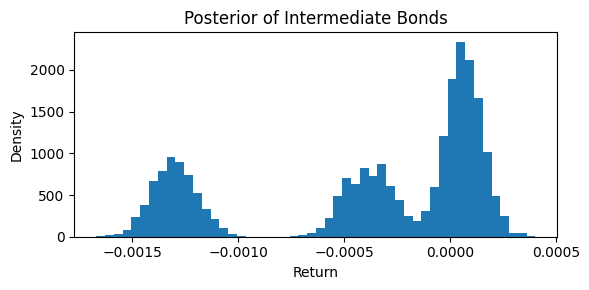

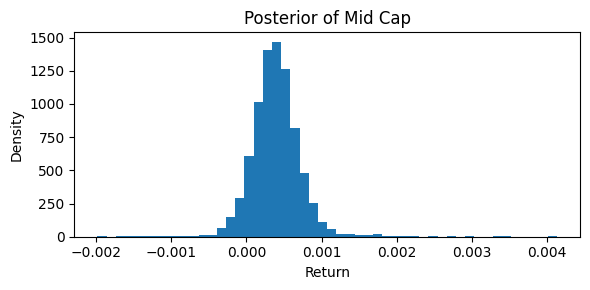

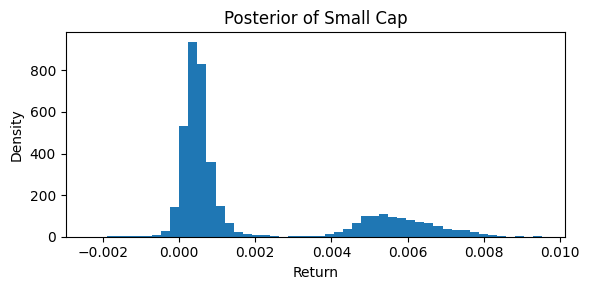

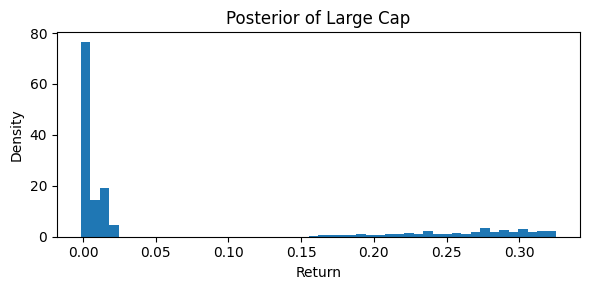

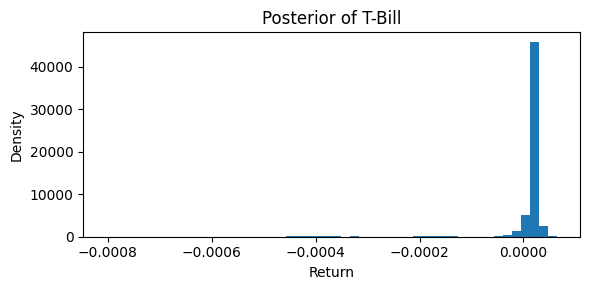

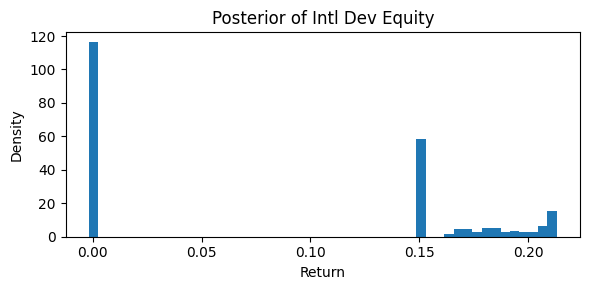

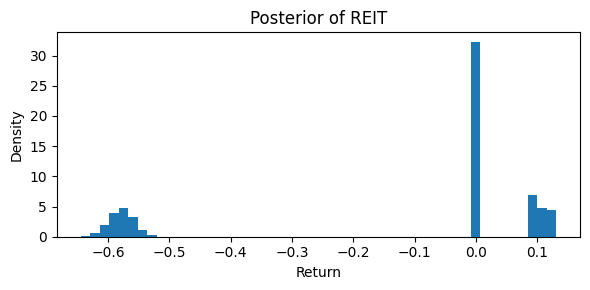

In [258]:
# Plot each posterior distribution
for i, asset in enumerate(asset_names):
    samples = trace.posterior["mu"].values[..., i].ravel()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(samples, bins=50, density=True)
    ax.set_title(f"Posterior of {asset}")
    ax.set_xlabel("Return")
    ax.set_ylabel("Density")
    plt.tight_layout()
    plt.show()

In [259]:
# Compute posterior‐based expected returns & covariance
posterior_means = posterior_metrics["Mean"].values

# use posterior draws of mu to get a covariance estimate
all_draws = trace.posterior["mu"].values  # shape (chains, draws, assets)

# reshape to (n_samples, n_assets)
n_chains, n_draws, n_assets = all_draws.shape
flat_draws = all_draws.reshape(n_chains * n_draws, n_assets)
cov_matrix = np.cov(flat_draws, rowvar=False)

In [260]:
# Run Section 3 optimizers
# each function should accept (expected_returns, cov) or in the CVar case the raw draws
w_mv     = optimize_mean_variance(posterior_means, cov_matrix)
w_sharpe = max_sharpe_ratio(        posterior_means, cov_matrix)

# For CVaR, pass alpha as the 3rd positional argument rather than by keyword:
#    (expected_returns, raw_draws, alpha)
w_cvar = optimize_cvar(flat_draws, alpha=0.05)

# put them in a DataFrame for easy comparison
asset_index = asset_names   # e.g. ['DBC','EEM','IEF',…] or ASSET_TICKERS.values()
weights_df = pd.DataFrame(
    {
        "Mean-Variance": w_mv,
        "Max-Sharpe":    w_sharpe,
        "CVaR (5%)":     w_cvar,
    },
    index=asset_index
)

# 3) Collect into a dict of pd.Series for downstream back-testing:
bayesian_portfolios = {
    strat: weights_df[strat]
    for strat in weights_df.columns
}

display(weights_df)

,Mean-Variance,Max-Sharpe,CVaR (5%)
Commodities,0.000000,7.798612e-13,0.000000e+00
Emerging Market Equity,0.149317,5.780394e-10,0.000000e+00
Intermediate Bonds,0.696781,9.907363e-01,2.775558e-17
Mid Cap,0.000000,6.126623e-10,1.804112e-16
Small Cap,0.040825,0.000000e+00,5.551115e-17
Large Cap,0.000000,2.525218e-11,6.938894e-17
T-Bill,0.112087,1.704575e-08,6.245005e-17
Intl Dev Equity,0.000989,9.263650e-03,4.007211e-16
REIT,0.000000,0.000000e+00,1.000000e+00


### Section 6: Back Test

In [261]:
# Fetch test prices & compute log‐returns
prices_test  = fetch_adjusted_close(ASSET_TICKERS, TEST_START, TEST_END)
returns_test = np.log(prices_test / prices_test.shift(1)).dropna()

# Unified performance helper
def portfolio_performance(weights, rets):
    """
    Compute:
      - cumulative growth of $1 invested, returned as a pd.Series indexed by date
      - accepts a dict or pd.Series of weights
    """
    # ensure weights series aligns with rets columns
    w = pd.Series(weights)
    port_ret = rets.mul(w, axis=1).sum(axis=1)
    return (1 + port_ret).cumprod()

In [262]:
# Build cumulative‐growth series for all 9 portfolios

cum_static = {
    f"Static – {name}": portfolio_performance(weights, returns_test)
    for name, weights in BASE_PORTFOLIO_WEIGHTS.items()
}
cum_mc = {
    f"Monte Carlo - {name}": portfolio_performance(weights, returns_test)
    for name, weights in mc_portfolios.items()
}
cum_bayes = {
    f"Bayesian – {name}": portfolio_performance(weights, returns_test)
    for name, weights in bayesian_portfolios.items()
}

In [263]:
# 4) Combine into one DataFrame
all_cum = pd.concat(
    [series.rename(name) for d in (cum_static, cum_mc, cum_bayes) for name, series in d.items()],
    axis=1
)

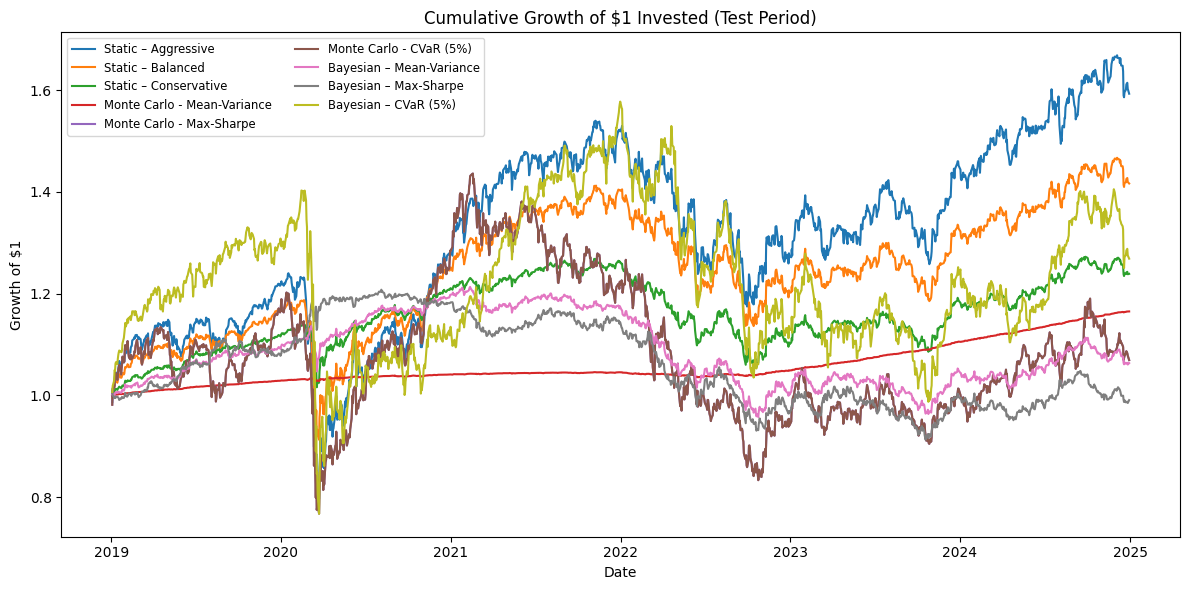

In [264]:
# 5) Plot cumulative growth of $1
plt.figure(figsize=(12, 6))
for col in all_cum.columns:
    plt.plot(all_cum.index, all_cum[col], label=col)
plt.title("Cumulative Growth of $1 Invested (Test Period)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend(loc="upper left", fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

In [265]:
# 6) Compute yearly returns and full‐period cumulative returns
#   a) Year‐end cumulative values → pct_change → drop first NaN
yearly_ret = (
    all_cum
      .resample('Y')
      .last()
      .pct_change()
      .dropna()
)
yearly_ret.index = yearly_ret.index.year  # turn to ints

#   b) Total cumulative return = final value ÷ $1 – 1
cum_return = all_cum.iloc[-1] - 1
cum_return = cum_return.to_frame(name="Cumulative Return")


<ipython-input-265-2718d0873560>:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y')


In [266]:
# 7) Display results
print("\n=== Yearly Returns ===")
display(yearly_ret.style.format("{:.2%}"))

print("\n=== Full‐Period Cumulative Returns ===")
display(cum_return.style.format("{:.2%}"))


=== Yearly Returns ===


,Static – Aggressive,Static – Balanced,Static – Conservative,Monte Carlo - Mean-Variance,Monte Carlo - Max-Sharpe,Monte Carlo - CVaR (5%),Bayesian – Mean-Variance,Bayesian – Max-Sharpe,Bayesian – CVaR (5%)
Date,,,,,,,,,
2020,5.47%,7.17%,8.50%,1.19%,10.11%,10.11%,9.78%,9.74%,-13.26%
2021,18.24%,12.03%,4.21%,0.41%,-5.16%,-5.16%,-2.03%,-3.33%,38.99%
2022,-16.18%,-14.30%,-12.80%,0.35%,-22.72%,-22.72%,-14.71%,-15.59%,-28.47%
2023,14.04%,10.52%,7.83%,5.40%,7.67%,7.67%,4.78%,3.32%,9.64%
2024,9.72%,6.66%,4.43%,5.37%,5.58%,5.58%,1.40%,-0.64%,2.57%



=== Full‐Period Cumulative Returns ===


,Cumulative Return
Static – Aggressive,59.28%
Static – Balanced,41.64%
Static – Conservative,23.89%
Monte Carlo - Mean-Variance,16.51%
Monte Carlo - Max-Sharpe,6.95%
Monte Carlo - CVaR (5%),6.95%
Bayesian – Mean-Variance,6.35%
Bayesian – Max-Sharpe,-0.92%
Bayesian – CVaR (5%),26.87%
